# Análisis exploratorio de datos (EDA)

Cargamos nuestro dataset

In [2]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd

#df = pd.read_csv("../data/diabetes_binary_health_indicators_BRFSS2015.csv")
#df = pd.read_csv("../data/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
df = pd.read_csv("../data/diabetes_012_health_indicators_BRFSS2015.csv")

Podemos observar que nuestro dataframe cuenta con **253680** registros y **22** atributos, todos númericos

In [3]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [4]:
pd.DataFrame({
    "Non-Null Count": df.notnull().sum(),
    "Null Count": df.isnull().sum(),
    "Dtype": df.dtypes
})

,Non-Null Count,Null Count,Dtype
Diabetes_012,253680,0,float64
HighBP,253680,0,float64
HighChol,253680,0,float64
CholCheck,253680,0,float64
BMI,253680,0,float64
Smoker,253680,0,float64
Stroke,253680,0,float64
HeartDiseaseorAttack,253680,0,float64
PhysActivity,253680,0,float64
Fruits,253680,0,float64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

## Porcentaje de afectados

Calculamos el porcentaje de personas con y sin diabetes.

Frecuencia relativa * 100 (con 2 decimales)

In [10]:
(df["Diabetes_012"].value_counts(normalize=True) * 100).round(2) # Porcentaje

Diabetes_012
0.0    85.81
1.0    14.19
Name: proportion, dtype: float64

In [12]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
1.0     35346
Name: count, dtype: int64

## Cantidad de valores únicos

In [8]:
df.nunique()

Diabetes_012             3
HighBP                   2
HighChol                 2
CholCheck                2
BMI                     84
Smoker                   2
Stroke                   2
HeartDiseaseorAttack     2
PhysActivity             2
Fruits                   2
Veggies                  2
HvyAlcoholConsump        2
AnyHealthcare            2
NoDocbcCost              2
GenHlth                  5
MentHlth                31
PhysHlth                31
DiffWalk                 2
Sex                      2
Age                     13
Education                6
Income                   8
dtype: int64

In [9]:
from utils import estandarizar_columnas_no_binarias

df = df[df["Diabetes_012"] != 1]
df["Diabetes_012"] = df["Diabetes_012"].replace(2, 1)

df = estandarizar_columnas_no_binarias(df, True)

df.std().round(2)
df.mean().round(2)

Columnas estandarizadas: ['BMI', 'GenHlth', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


Diabetes_012            0.14
HighBP                  0.43
HighChol                0.42
CholCheck               0.96
BMI                    -0.00
Smoker                  0.44
Stroke                  0.04
HeartDiseaseorAttack    0.09
PhysActivity            0.76
Fruits                  0.63
Veggies                 0.81
HvyAlcoholConsump       0.06
AnyHealthcare           0.95
NoDocbcCost             0.08
GenHlth                 0.00
MentHlth               -0.00
PhysHlth                0.00
DiffWalk                0.17
Sex                     0.44
Age                     0.00
Education              -0.00
Income                 -0.00
dtype: float64

In [29]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,249049.000000,249049.000000,249049.000000,249049.000000,2.490490e+05,249049.000000,249049.000000,249049.000000,249049.000000,249049.000000,...,249049.000000,249049.000000,2.490490e+05,2.490490e+05,2.490490e+05,249049.000000,249049.000000,2.490490e+05,2.490490e+05,2.490490e+05
mean,0.141924,0.425282,0.420463,0.962224,-1.153192e-16,0.442246,0.040261,0.093271,0.757995,0.634851,...,0.951162,0.083337,1.743768e-16,-8.673192e-18,2.967145e-17,0.166192,0.440391,2.013094e-16,-2.528920e-16,-1.314673e-16
std,0.348973,0.494387,0.493634,0.190654,1.000000e+00,0.496654,0.196571,0.290812,0.428298,0.481473,...,0.215529,0.276392,1.000000e+00,1.000000e+00,1.000000e+00,0.372254,0.496435,1.000000e+00,1.000000e+00,1.000000e+00
min,0.000000,0.000000,0.000000,0.000000,-2.477819e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1.407991e+00,-4.281448e-01,-4.841492e-01,0.000000,0.000000,-2.293121e+00,-4.123937e+00,-2.452246e+00
25%,0.000000,0.000000,0.000000,1.000000,-6.579911e-01,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,-4.710546e-01,-4.281448e-01,-4.841492e-01,0.000000,0.000000,-6.581140e-01,-1.073220e+00,-5.163679e-01
50%,0.000000,0.000000,0.000000,1.000000,-2.030341e-01,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,-4.710546e-01,-4.281448e-01,-4.841492e-01,0.000000,0.000000,-4.111005e-03,-5.631487e-02,4.515714e-01
75%,0.000000,1.000000,1.000000,1.000000,4.035752e-01,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.658817e-01,-1.571465e-01,-1.385683e-01,0.000000,1.000000,6.498920e-01,9.605907e-01,9.355411e-01
max,1.000000,1.000000,1.000000,1.000000,1.056428e+01,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,2.339754e+00,3.636830e+00,2.971660e+00,1.000000,1.000000,1.630896e+00,9.605907e-01,9.355411e-01


## Correlación de atributos

Calculamos la matriz de correlación, esto lo que hace es medir el grado de asosiación lineal entre cada par de atributos de nuestros datos. Se calcula de la siguiente manera:

$\rho(X, Y) = \frac{Cov(X, Y)}{s_x s_y}$  

Y la covarianza se calcula como:  

$Cov(X, Y) = \frac{1}{n} \sum_{i=1}^n(x_i - \bar{x})(y_i - \bar{y})$

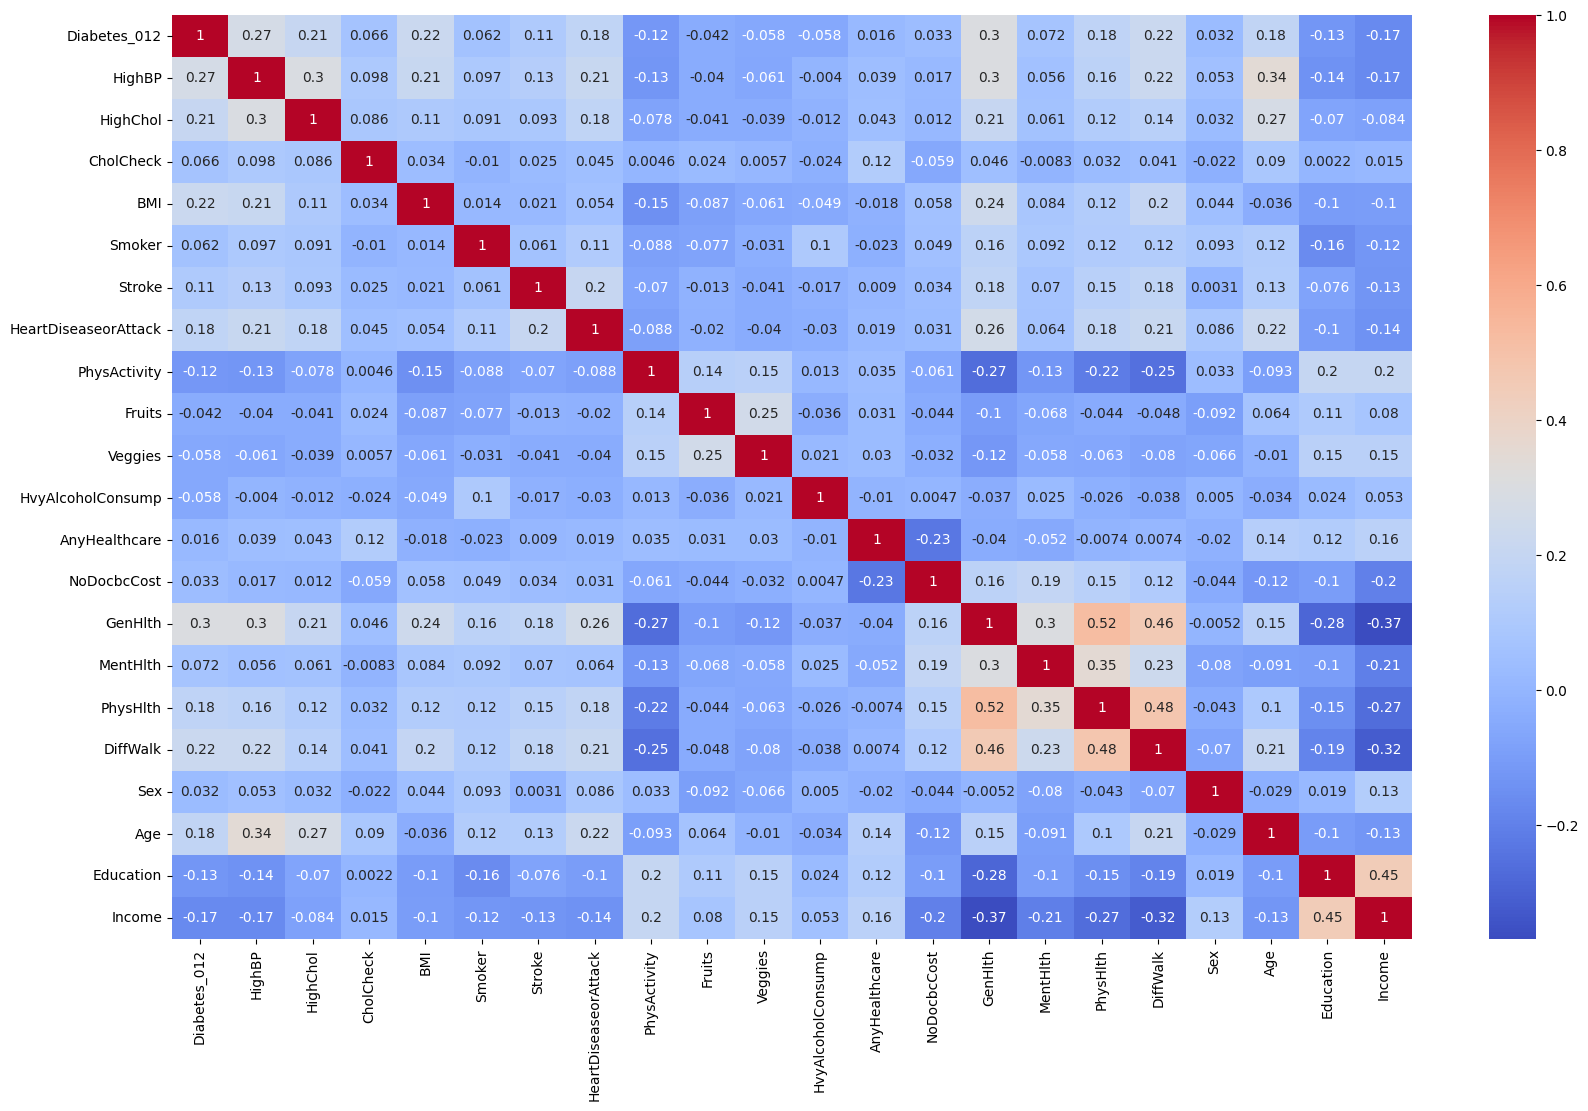

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 12))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## Distribución de los datos

Nota: para la elección del ancho de los bins en los histogramas se utilizó la regla de -nombre-.



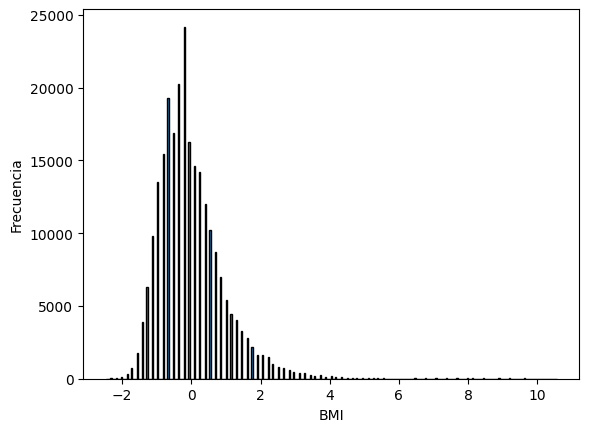

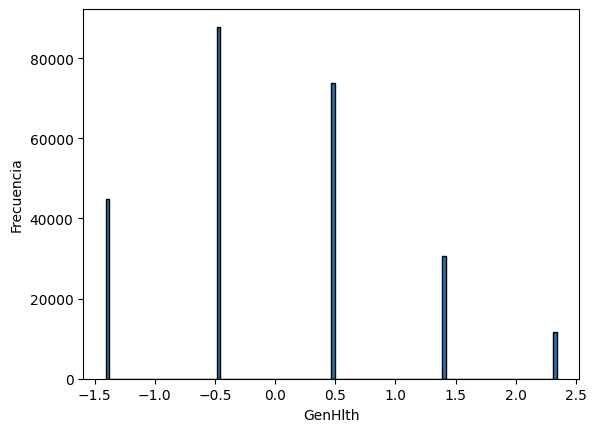

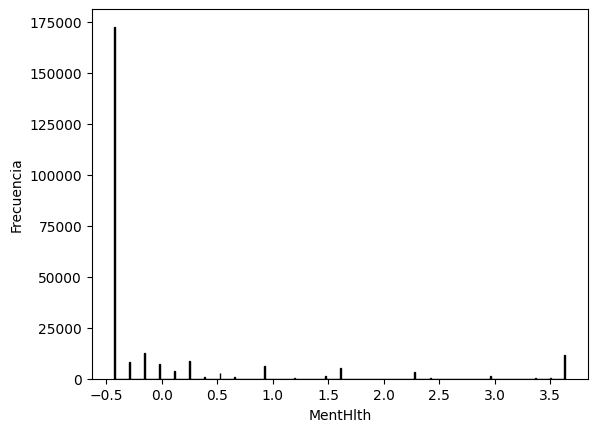

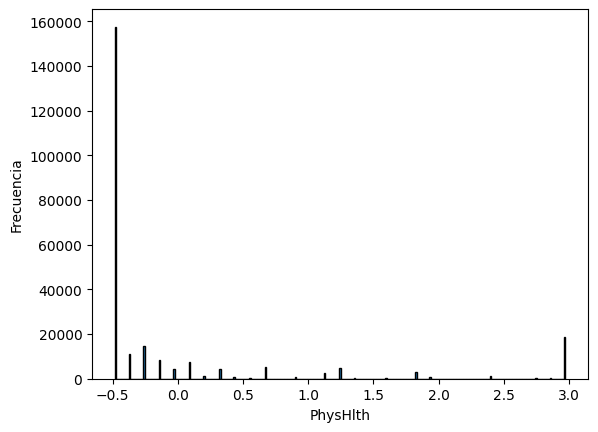

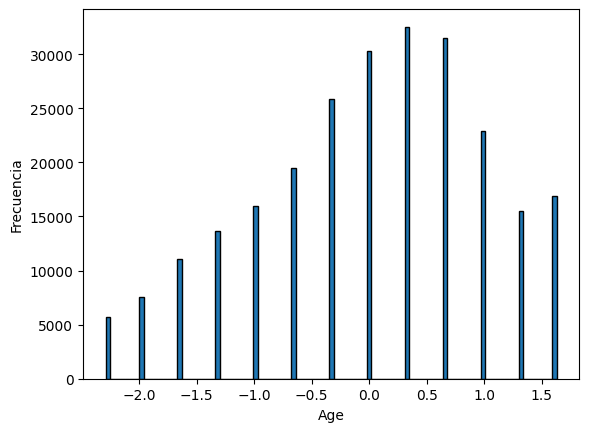

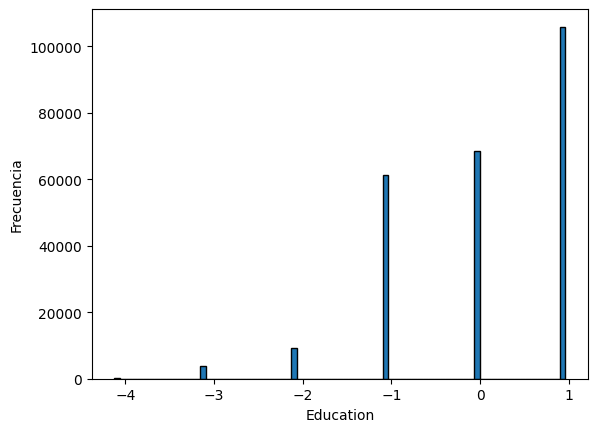

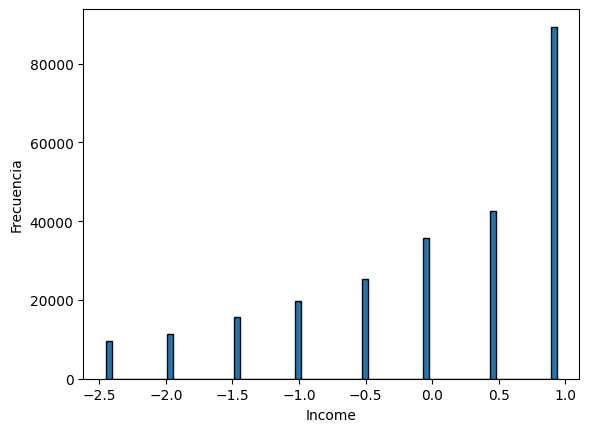

In [14]:
atributos = ["BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income"]

for atributo in atributos:
    plt.hist(df[atributo], bins="auto", edgecolor="black")
    plt.xlabel(atributo)
    plt.ylabel("Frecuencia")
    plt.show()

# Preparación de datos

Separar del dataframe a los atributos y al concepto

In [ ]:
atributos = df.drop(columns=["Diabetes_binary"])
#x.columns.to_list()
y_no = df["Diabetes_binary"]
concepto = df[["Diabetes_binary"]]
print(type(y_no))
print(type(concepto))

Pasar de DataFrame a array de numpy

In [ ]:
import numpy as np

x = atributos.to_numpy()
print(f"Shape de x: {x.shape}")

y = concepto.to_numpy()
print(f"Shape de y: {y.shape}")

In [8]:
df.shape

(249049, 22)

In [37]:
df = df.drop(df[df["Diabetes_012"] == 1.0].index)

In [32]:
df.shape

(249049, 22)